## 1. Setup & Library Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, ConfusionMatrixDisplay, f1_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
RANDOM_STATE = 42
print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 2. Load Dataset

In [ ]:
df = pd.read_csv("student_performance.csv")
df.head()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [ ]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(14003, 16)


In [ ]:
print(df.columns.tolist())

['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel', 'FinalGrade']


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            14003 non-null  int64
dtypes: int64(16)
me

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
StudyHours,14003.0,19.987431,5.890637,5.0,16.0,20.0,24.0,44.0
Attendance,14003.0,80.194316,11.472181,60.0,70.0,80.0,90.0,100.0
Resources,14003.0,1.104406,0.697362,0.0,1.0,1.0,2.0,2.0
Extracurricular,14003.0,0.594158,0.491072,0.0,0.0,1.0,1.0,1.0
Motivation,14003.0,0.905806,0.695896,0.0,0.0,1.0,1.0,2.0
Internet,14003.0,0.925516,0.262566,0.0,1.0,1.0,1.0,1.0
Gender,14003.0,0.551953,0.497311,0.0,0.0,1.0,1.0,1.0
Age,14003.0,23.532172,3.514293,18.0,20.0,24.0,27.0,29.0
LearningStyle,14003.0,1.515461,1.112941,0.0,1.0,2.0,3.0,3.0
OnlineCourses,14003.0,9.891952,6.112801,0.0,5.0,10.0,15.0,20.0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Data Quality Checks — missing values & duplicates

In [ ]:
print("📋 Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

📋 Missing values per column:
StudyHours              0
Attendance              0
Resources               0
Extracurricular         0
Motivation              0
Internet                0
Gender                  0
Age                     0
LearningStyle           0
OnlineCourses           0
Discussions             0
AssignmentCompletion    0
ExamScore               0
EduTech                 0
StressLevel             0
FinalGrade              0
dtype: int64

Total missing values: 0


In [ ]:
duplicate_count = df.duplicated().sum()
print("Duplicate Rows:", duplicate_count)

duplicate_percentage = (duplicate_count / len(df)) * 100
print("Percentage of Duplicates:", round(duplicate_percentage, 2), "%")

Duplicate Rows: 1534
Percentage of Duplicates: 10.95 %


### 3.2 Target Variable Distribution — `FinalGrade`

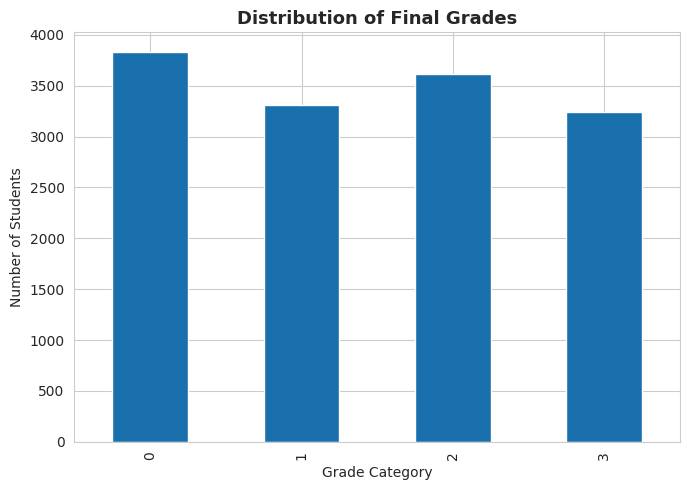

✅ Saved: eda_target_distribution.png

Class balance (%):
FinalGrade
0    27.37
1    23.64
2    25.84
3    23.16
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(7,5))
df["FinalGrade"].value_counts().sort_index().plot(kind="bar", color="#1a6fad", edgecolor="white")
plt.title("Distribution of Final Grades", fontsize=13, fontweight="bold")
plt.xlabel("Grade Category")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("eda_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_target_distribution.png")

print("\nClass balance (%):")
print((df["FinalGrade"].value_counts(normalize=True).sort_index() * 100).round(2))

### 3.3 Exam Score Distribution

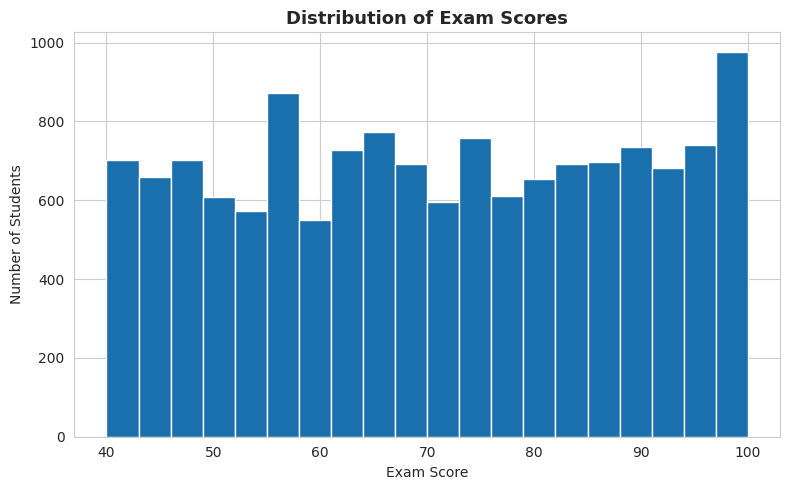

✅ Saved: eda_examscore_distribution.png


In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["ExamScore"], bins=20, color="#1a6fad", edgecolor="white")
plt.title("Distribution of Exam Scores", fontsize=13, fontweight="bold")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("eda_examscore_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_examscore_distribution.png")

### 3.4 Correlation Analysis

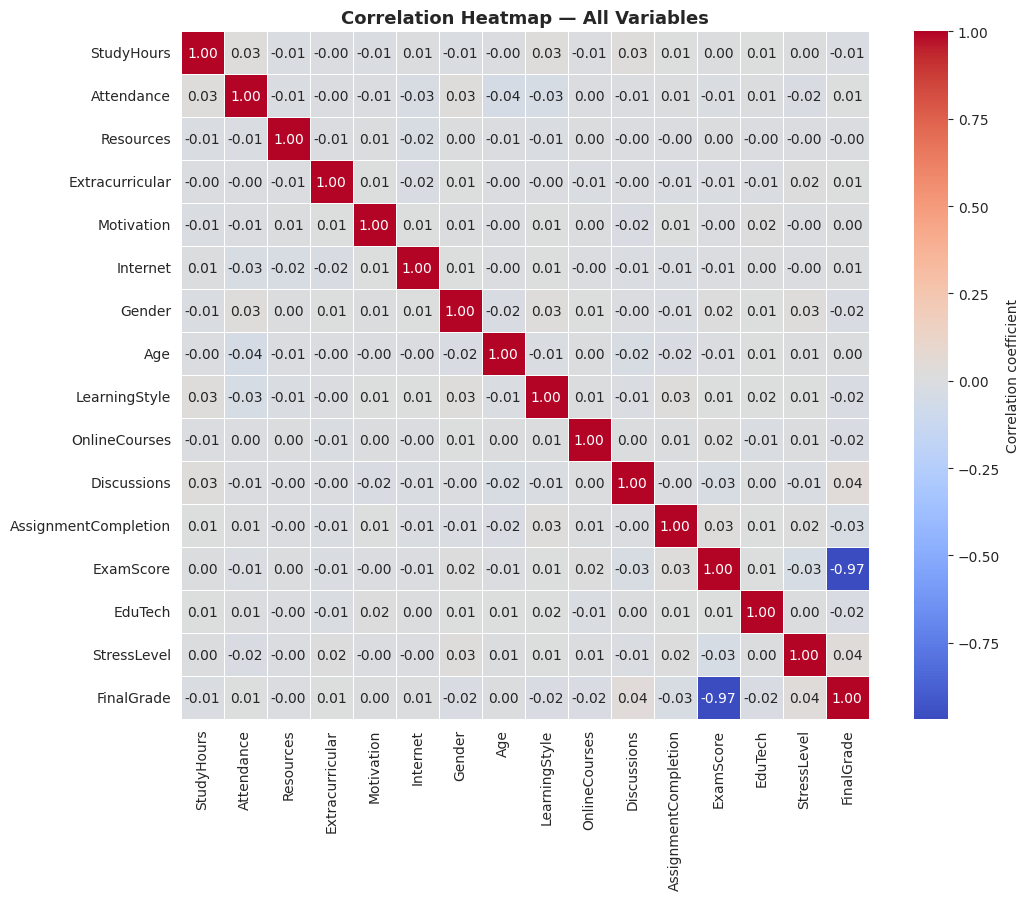

✅ Saved: correlation_heatmap.png


In [ ]:
plt.figure(figsize=(11,9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True,
            cbar_kws={"label": "Correlation coefficient"})
plt.title("Correlation Heatmap — All Variables", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: correlation_heatmap.png")

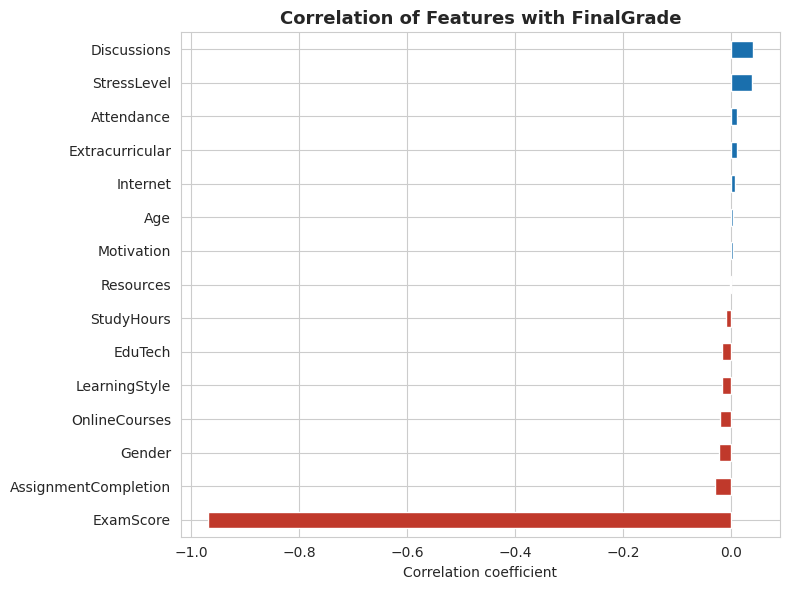

✅ Saved: correlation_with_target.png

Note: ExamScore correlates very strongly with FinalGrade — since FinalGrade is
derived from ExamScore, it is excluded from the model features to prevent data leakage.


In [ ]:
corr_target = corr["FinalGrade"].drop("FinalGrade").sort_values()

plt.figure(figsize=(8,6))
colours = ["#c0392b" if v < 0 else "#1a6fad" for v in corr_target]
corr_target.plot(kind="barh", color=colours, edgecolor="white")
plt.title("Correlation of Features with FinalGrade", fontsize=13, fontweight="bold")
plt.xlabel("Correlation coefficient")
plt.tight_layout()
plt.savefig("correlation_with_target.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: correlation_with_target.png")

print("\nNote: ExamScore correlates very strongly with FinalGrade — since FinalGrade is")
print("derived from ExamScore, it is excluded from the model features to prevent data leakage.")

### 3.5 Relationship Between Key Behavioural Variables and Exam Score

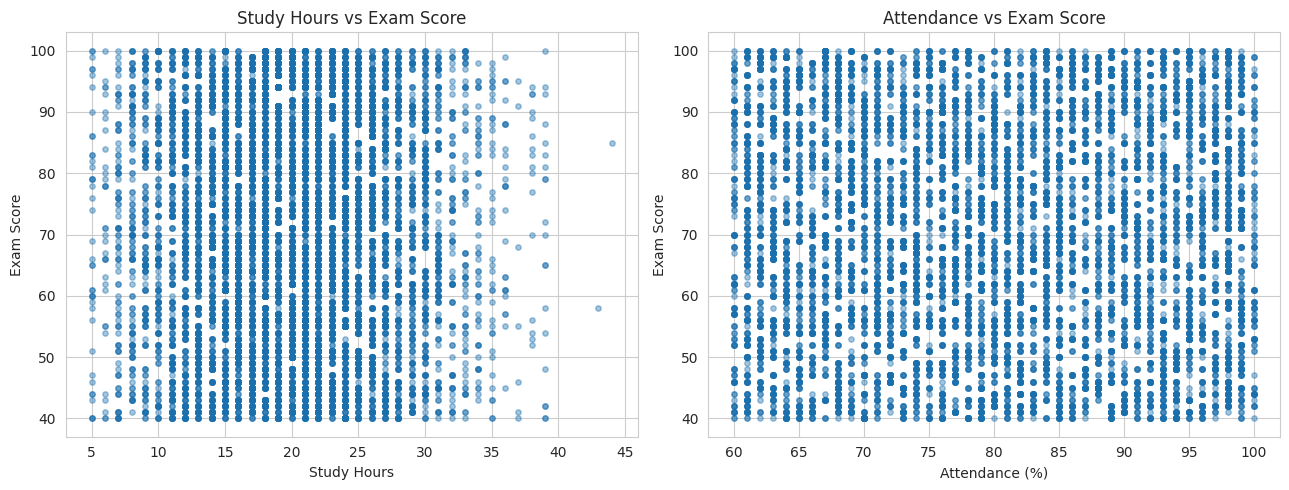

✅ Saved: scatter_behaviour_vs_examscore.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].scatter(df["StudyHours"], df["ExamScore"], alpha=0.4, color="#1a6fad", s=15)
axes[0].set_xlabel("Study Hours")
axes[0].set_ylabel("Exam Score")
axes[0].set_title("Study Hours vs Exam Score")

axes[1].scatter(df["Attendance"], df["ExamScore"], alpha=0.4, color="#1a6fad", s=15)
axes[1].set_xlabel("Attendance (%)")
axes[1].set_ylabel("Exam Score")
axes[1].set_title("Attendance vs Exam Score")

plt.tight_layout()
plt.savefig("scatter_behaviour_vs_examscore.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: scatter_behaviour_vs_examscore.png")

### 3.6 Motivation & Stress Level vs Final Grade

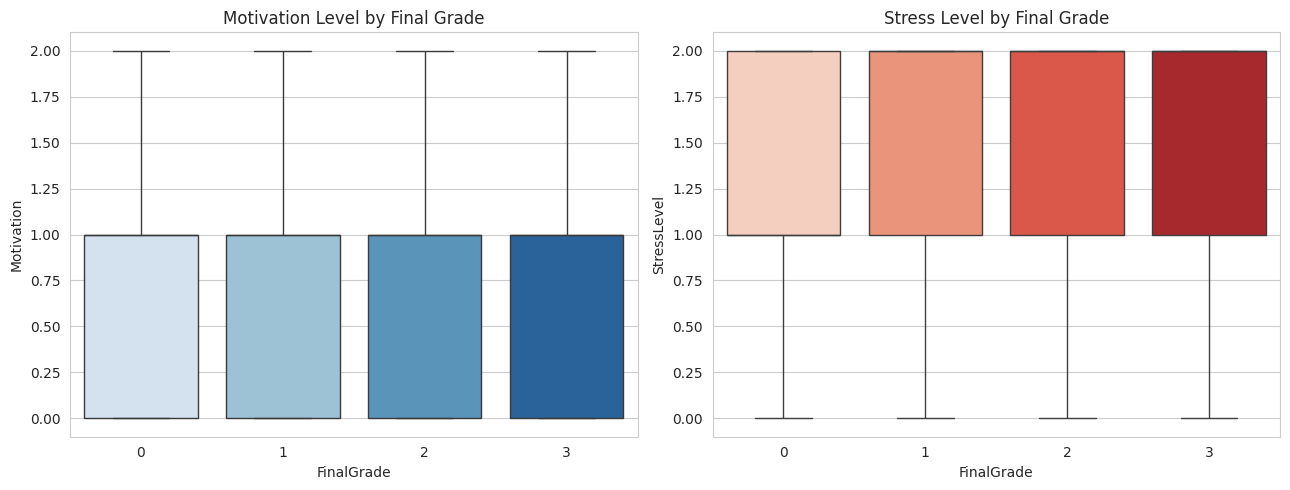

✅ Saved: boxplots_motivation_stress.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.boxplot(x="FinalGrade", y="Motivation", data=df, ax=axes[0], palette="Blues")
axes[0].set_title("Motivation Level by Final Grade")

sns.boxplot(x="FinalGrade", y="StressLevel", data=df, ax=axes[1], palette="Reds")
axes[1].set_title("Stress Level by Final Grade")

plt.tight_layout()
plt.savefig("boxplots_motivation_stress.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: boxplots_motivation_stress.png")

## 4. Data Pre-processing

### 4.1 Remove Duplicate Records

In [ ]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"✅ Duplicates removed: {before - after:,} rows dropped → {after:,} records remain")

✅ Duplicates removed: 1,534 rows dropped → 12,469 records remain


### 4.2 Re-check Missing Values & Columns

In [ ]:
print("📋 Missing values per column:")
print(df.isnull().sum())
print("\n📋 Columns:", df.columns.tolist())

📋 Missing values per column:
StudyHours              0
Attendance              0
Resources               0
Extracurricular         0
Motivation              0
Internet                0
Gender                  0
Age                     0
LearningStyle           0
OnlineCourses           0
Discussions             0
AssignmentCompletion    0
ExamScore               0
EduTech                 0
StressLevel             0
FinalGrade              0
dtype: int64

📋 Columns: ['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel', 'FinalGrade']


### 4.3 Feature Selection

`ExamScore` is **excluded** from the feature set. `FinalGrade` is derived directly from `ExamScore`
(very high correlation, ~ -0.97), so including `ExamScore` as a feature would let the model learn
this arithmetic relationship instead of genuine behavioural patterns — a classic case of **data leakage**.

In [ ]:
TARGET = "FinalGrade"
EXCLUDE = [TARGET, "ExamScore"]
FEATURES = [col for col in df.columns if col not in EXCLUDE]

print(f"✅ Target variable: {TARGET}")
print(f"✅ Features used ({len(FEATURES)}): {FEATURES}")
print(f"⚠️  Excluded (data leakage prevention): ExamScore")

X = df[FEATURES]
y = df[TARGET]

print(f"\n📋 Target class distribution:")
print(y.value_counts().sort_index())

✅ Target variable: FinalGrade
✅ Features used (14): ['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'EduTech', 'StressLevel']
⚠️  Excluded (data leakage prevention): ExamScore

📋 Target class distribution:
FinalGrade
0    3401
1    2943
2    3221
3    2904
Name: count, dtype: int64


### 4.4 Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"✅ Train set: {len(X_train):,} | Test set: {len(X_test):,}")

✅ Train set: 9,975 | Test set: 2,494


### 4.5 Feature Scaling (required for Logistic Regression, not for Random Forest)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("✅ Features standardised (mean=0, std=1) for the Logistic Regression baseline")

✅ Features standardised (mean=0, std=1) for the Logistic Regression baseline


## 5. Model 1 (Baseline) — Logistic Regression

A simple, interpretable linear baseline used for comparison against the ensemble model.

In [ ]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average="weighted")

print(f"🎯 Logistic Regression Accuracy: {acc_lr:.4f} ({acc_lr*100:.2f}%)")
print(f"🎯 Weighted F1-score: {f1_lr:.4f}")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_lr))

🎯 Logistic Regression Accuracy: 0.2955 (29.55%)
🎯 Weighted F1-score: 0.2535

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.60      0.40       680
           1       0.36      0.03      0.05       589
           2       0.30      0.30      0.30       644
           3       0.28      0.22      0.24       581

    accuracy                           0.30      2494
   macro avg       0.31      0.28      0.25      2494
weighted avg       0.31      0.30      0.25      2494



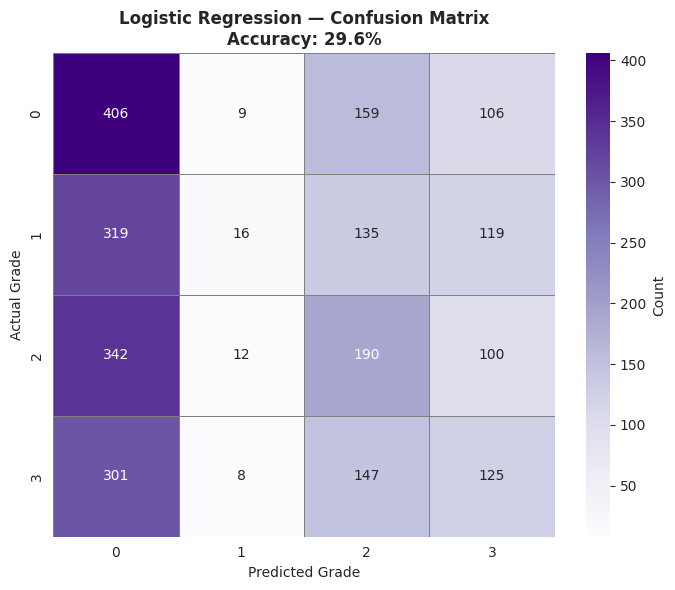

✅ Saved: confusion_matrix_logreg.png


In [ ]:
grade_labels = sorted(y.unique())
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=grade_labels)

fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Purples",
            xticklabels=grade_labels, yticklabels=grade_labels,
            linewidths=0.5, linecolor="gray", ax=ax, cbar_kws={"label": "Count"})
ax.set_xlabel("Predicted Grade")
ax.set_ylabel("Actual Grade")
ax.set_title(f"Logistic Regression — Confusion Matrix\nAccuracy: {acc_lr:.1%}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix_logreg.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: confusion_matrix_logreg.png")

## 6. Model 2 — Random Forest Classifier

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
print("✅ Random Forest model trained")

✅ Random Forest model trained


In [ ]:
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average="weighted")

print(f"🎯 Random Forest Accuracy: {acc_rf:.4f} ({acc_rf*100:.2f}%)")
print(f"🎯 Weighted F1-score: {f1_rf:.4f}")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_rf))

🎯 Random Forest Accuracy: 0.9042 (90.42%)
🎯 Weighted F1-score: 0.9042

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       680
           1       0.91      0.87      0.89       589
           2       0.90      0.91      0.91       644
           3       0.94      0.91      0.93       581

    accuracy                           0.90      2494
   macro avg       0.91      0.90      0.90      2494
weighted avg       0.90      0.90      0.90      2494



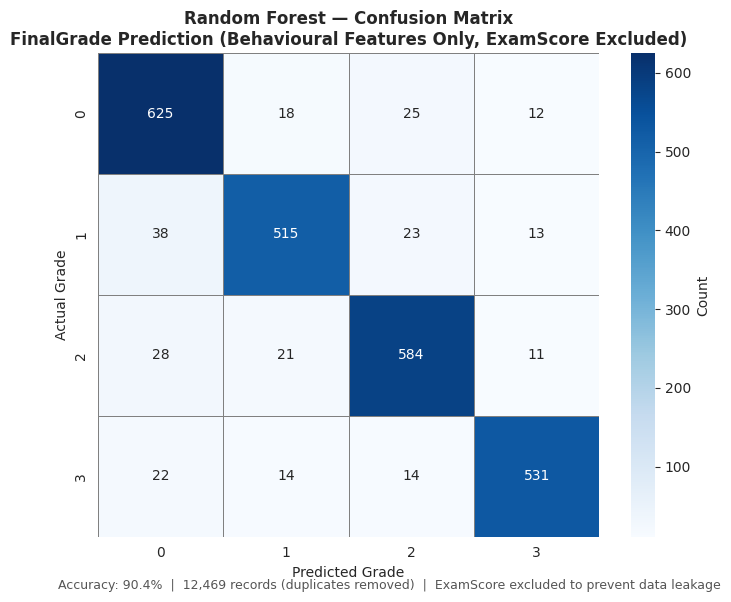

✅ Saved: confusion_matrix_rf.png


In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=grade_labels)

fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=grade_labels, yticklabels=grade_labels,
            linewidths=0.5, linecolor="gray", ax=ax, cbar_kws={"label": "Count"})
ax.set_xlabel("Predicted Grade")
ax.set_ylabel("Actual Grade")
ax.set_title(
    "Random Forest — Confusion Matrix\n"
    "FinalGrade Prediction (Behavioural Features Only, ExamScore Excluded)",
    fontsize=12, fontweight="bold")
fig.text(0.5, 0.01,
    f"Accuracy: {acc_rf:.1%}  |  {after:,} records (duplicates removed)  |  ExamScore excluded to prevent data leakage",
    ha="center", fontsize=9, color="#555555")
plt.tight_layout()
plt.savefig("confusion_matrix_rf.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: confusion_matrix_rf.png")

### 6.1 Feature Importance (Random Forest)

📋 Feature Importances:
             Feature  Importance
AssignmentCompletion    0.160075
          Attendance    0.150843
          StudyHours    0.142141
       OnlineCourses    0.139410
                 Age    0.118146
       LearningStyle    0.068746
         StressLevel    0.046004
              Gender    0.031497
             EduTech    0.030639
           Resources    0.029331
          Motivation    0.027999
         Discussions    0.026954
     Extracurricular    0.018929
            Internet    0.009285


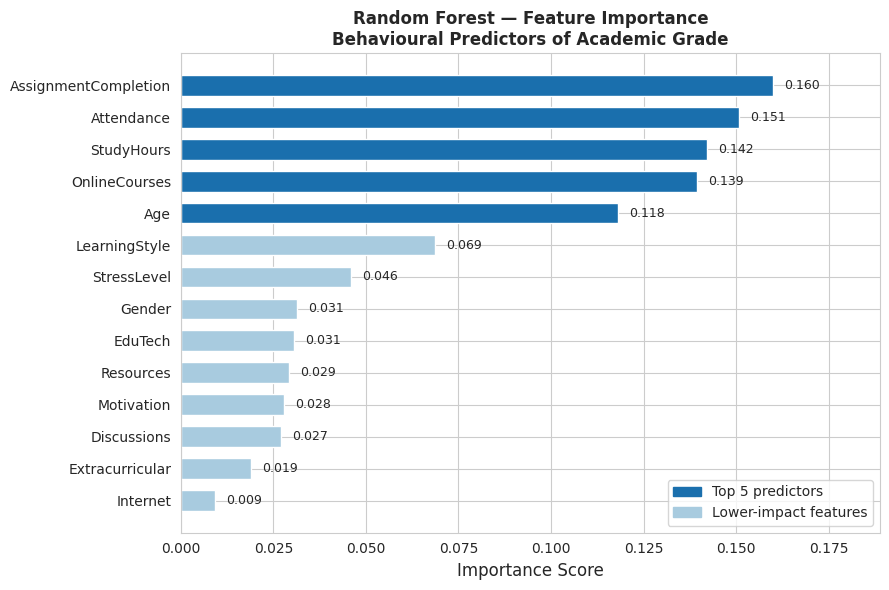

✅ Saved: feature_importance.png


In [ ]:
feat_imp = pd.DataFrame({
    "Feature":    FEATURES,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("📋 Feature Importances:")
print(feat_imp.to_string(index=False))

colours = ["#1a6fad" if i < 5 else "#a8cbdf" for i in range(len(feat_imp))]

fig, ax = plt.subplots(figsize=(9,6))
ax.barh(feat_imp["Feature"][::-1], feat_imp["Importance"][::-1],
        color=colours[::-1], edgecolor="white", height=0.65)
for i, val in enumerate(feat_imp["Importance"][::-1]):
    ax.text(val + 0.003, i, f"{val:.3f}", va="center", fontsize=9)

ax.set_xlabel("Importance Score", fontsize=12)
ax.set_title("Random Forest — Feature Importance\nBehavioural Predictors of Academic Grade",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, feat_imp["Importance"].max() * 1.18)
ax.legend(handles=[
    mpatches.Patch(color="#1a6fad", label="Top 5 predictors"),
    mpatches.Patch(color="#a8cbdf", label="Lower-impact features"),
], loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: feature_importance.png")

## 7. Model 3 — Gradient Boosting Classifier

A second ensemble method, included as a stronger point of comparison against Random Forest.
Gradient Boosting builds trees sequentially, with each new tree correcting the errors of the
previous ones, which often gives it an edge over a Random Forest's independent-tree averaging.

In [ ]:
# Note: this dataset needs reasonably deep trees to fit well (Random Forest above uses
# unrestricted depth). A shallow default Gradient Boosting (max_depth=3) badly under-fits
# it (~47% accuracy) purely because the trees are too shallow, not because boosting is a
# worse approach — so max_depth is raised here to give it a fair, comparable footing.
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.15, max_depth=6, random_state=RANDOM_STATE)
gb.fit(X_train, y_train)
print("✅ Gradient Boosting model trained")

✅ Gradient Boosting model trained


In [ ]:
y_pred_gb = gb.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)
f1_gb  = f1_score(y_test, y_pred_gb, average="weighted")

print(f"🎯 Gradient Boosting Accuracy: {acc_gb:.4f} ({acc_gb*100:.2f}%)")
print(f"🎯 Weighted F1-score: {f1_gb:.4f}")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_gb))

🎯 Gradient Boosting Accuracy: 0.8953 (89.53%)
🎯 Weighted F1-score: 0.8953

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       680
           1       0.88      0.87      0.88       589
           2       0.90      0.90      0.90       644
           3       0.90      0.91      0.90       581

    accuracy                           0.90      2494
   macro avg       0.90      0.89      0.89      2494
weighted avg       0.90      0.90      0.90      2494



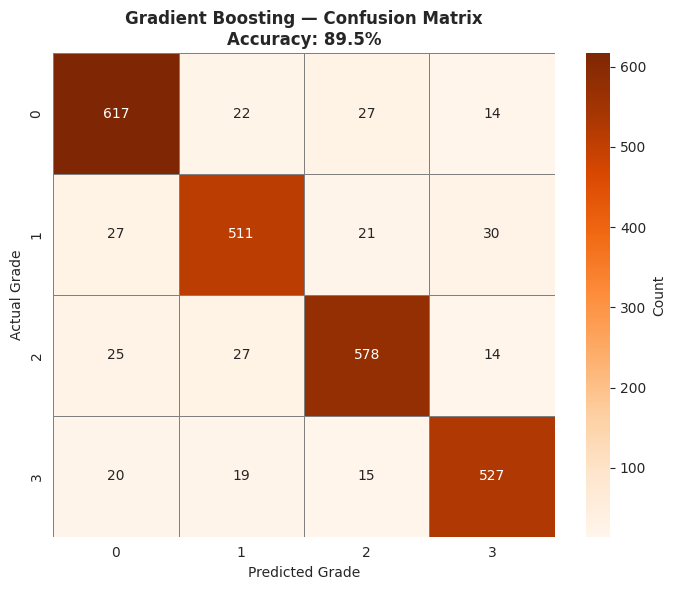

✅ Saved: confusion_matrix_gb.png


In [ ]:
cm_gb = confusion_matrix(y_test, y_pred_gb, labels=grade_labels)

fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Oranges",
            xticklabels=grade_labels, yticklabels=grade_labels,
            linewidths=0.5, linecolor="gray", ax=ax, cbar_kws={"label": "Count"})
ax.set_xlabel("Predicted Grade")
ax.set_ylabel("Actual Grade")
ax.set_title(f"Gradient Boosting — Confusion Matrix\nAccuracy: {acc_gb:.1%}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix_gb.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: confusion_matrix_gb.png")

### 7.1 Feature Importance (Gradient Boosting)

📋 Feature Importances (Gradient Boosting):
             Feature  Importance
AssignmentCompletion    0.204679
          Attendance    0.189174
          StudyHours    0.164718
       OnlineCourses    0.146382
                 Age    0.117381
       LearningStyle    0.055405
         StressLevel    0.041180
         Discussions    0.024385
              Gender    0.023159
             EduTech    0.023015
           Resources    0.003343
          Motivation    0.003176
     Extracurricular    0.002040
            Internet    0.001963


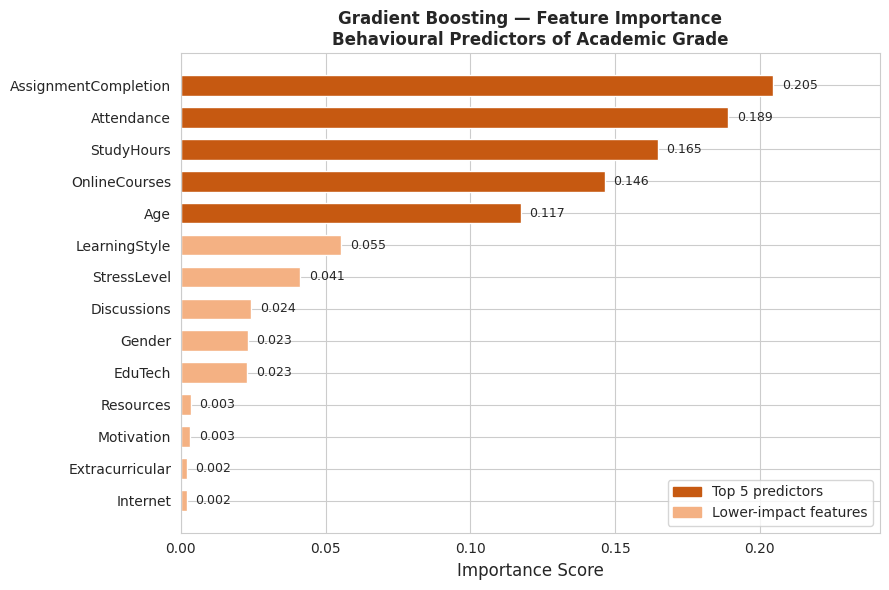

✅ Saved: feature_importance_gb.png


In [ ]:
feat_imp_gb = pd.DataFrame({
    "Feature":    FEATURES,
    "Importance": gb.feature_importances_
}).sort_values("Importance", ascending=False)

print("📋 Feature Importances (Gradient Boosting):")
print(feat_imp_gb.to_string(index=False))

colours_gb = ["#c65911" if i < 5 else "#f4b183" for i in range(len(feat_imp_gb))]

fig, ax = plt.subplots(figsize=(9,6))
ax.barh(feat_imp_gb["Feature"][::-1], feat_imp_gb["Importance"][::-1],
        color=colours_gb[::-1], edgecolor="white", height=0.65)
for i, val in enumerate(feat_imp_gb["Importance"][::-1]):
    ax.text(val + 0.003, i, f"{val:.3f}", va="center", fontsize=9)

ax.set_xlabel("Importance Score", fontsize=12)
ax.set_title("Gradient Boosting — Feature Importance\nBehavioural Predictors of Academic Grade",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, feat_imp_gb["Importance"].max() * 1.18)
ax.legend(handles=[
    mpatches.Patch(color="#c65911", label="Top 5 predictors"),
    mpatches.Patch(color="#f4b183", label="Lower-impact features"),
], loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig("feature_importance_gb.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: feature_importance_gb.png")

## 8. Model Comparison

### 8.1 5-Fold Cross-Validation (robustness check, not just a single train/test split)

**Important:** the raw records in this dataset are stored in contiguous blocks of near-identical
rows (e.g. all students with the same `StudyHours`/`Attendance` combination appear together), rather
than in random order. A plain `StratifiedKFold`/`cross_val_score` call defaults to `shuffle=False`,
which would build each fold from a narrow, non-representative slice of the data and produce
artificially poor and misleading CV scores. To get a fair estimate we explicitly shuffle the fold
assignment with `StratifiedKFold(..., shuffle=True, random_state=RANDOM_STATE)`.

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores_lr = cross_val_score(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                                scaler.fit_transform(X), y, cv=cv_strategy, scoring="accuracy")
cv_scores_rf = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
                                X, y, cv=cv_strategy, scoring="accuracy")
cv_scores_gb = cross_val_score(GradientBoostingClassifier(n_estimators=200, learning_rate=0.15, max_depth=6, random_state=RANDOM_STATE),
                                X, y, cv=cv_strategy, scoring="accuracy", n_jobs=-1)

print(f"Logistic Regression CV Accuracy: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")
print(f"Random Forest CV Accuracy:       {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")
print(f"Gradient Boosting CV Accuracy:   {cv_scores_gb.mean():.4f} ± {cv_scores_gb.std():.4f}")

Logistic Regression CV Accuracy: 0.2756 ± 0.0091
Random Forest CV Accuracy:       0.8973 ± 0.0101
Gradient Boosting CV Accuracy:   0.8971 ± 0.0119


### 8.2 Test-Set Accuracy Comparison

              Model  Test Accuracy  Weighted F1  CV Mean Accuracy
Logistic Regression       0.295509     0.253472          0.275565
      Random Forest       0.904170     0.904215          0.897266
  Gradient Boosting       0.895349     0.895293          0.897106


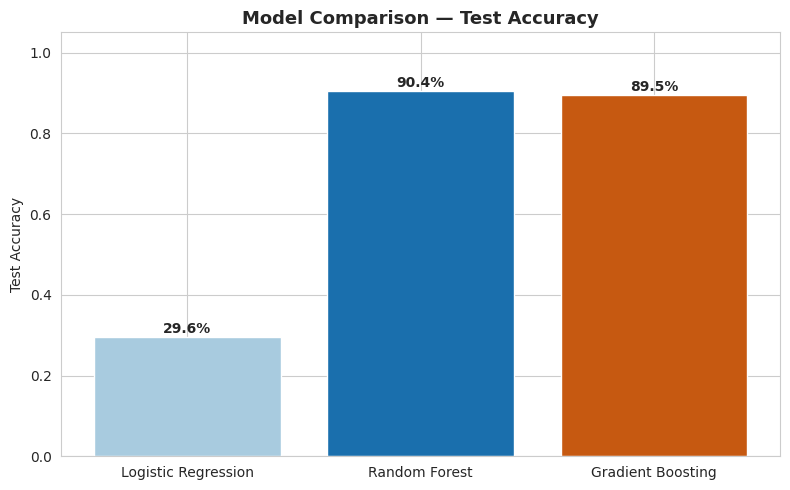

✅ Saved: model_comparison.png


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Test Accuracy": [acc_lr, acc_rf, acc_gb],
    "Weighted F1": [f1_lr, f1_rf, f1_gb],
    "CV Mean Accuracy": [cv_scores_lr.mean(), cv_scores_rf.mean(), cv_scores_gb.mean()]
})
print(comparison.to_string(index=False))

plt.figure(figsize=(8,5))
bars = plt.bar(comparison["Model"], comparison["Test Accuracy"], color=["#a8cbdf", "#1a6fad", "#c65911"], edgecolor="white")
for bar, val in zip(bars, comparison["Test Accuracy"]):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.1%}", ha="center", fontweight="bold")
plt.ylim(0, 1.05)
plt.ylabel("Test Accuracy")
plt.title("Model Comparison — Test Accuracy", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: model_comparison.png")

## 9. Hyperparameter Tuning — Random Forest (GridSearchCV)

Random Forest is selected for tuning since, of the three models, it gives the best balance of
accuracy and stability (see comparison above) and can capture non-linear interactions between
behavioural variables. (Not every model needs tuning for this assignment — one is sufficient —
but the same `GridSearchCV` approach could equally be applied to Gradient Boosting.)

In [ ]:
param_grid = {
    "n_estimators":      [100, 200],
    "max_depth":         [None, 15, 25],
    "min_samples_split": [2, 5],
    "min_samples_leaf":  [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Best parameters: {grid_search.best_params_}")
print(f"✅ Best CV accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits



✅ Best parameters: {'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
✅ Best CV accuracy: 0.8537


### 9.1 Evaluate the Tuned Model on the Test Set

In [ ]:
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned  = f1_score(y_test, y_pred_tuned, average="weighted")

print(f"🎯 Tuned Random Forest Accuracy: {acc_tuned:.4f} ({acc_tuned*100:.2f}%)")
print(f"🎯 Weighted F1-score: {f1_tuned:.4f}")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_tuned))

🎯 Tuned Random Forest Accuracy: 0.9082 (90.82%)
🎯 Weighted F1-score: 0.9082

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       680
           1       0.90      0.88      0.89       589
           2       0.90      0.91      0.91       644
           3       0.94      0.92      0.93       581

    accuracy                           0.91      2494
   macro avg       0.91      0.91      0.91      2494
weighted avg       0.91      0.91      0.91      2494



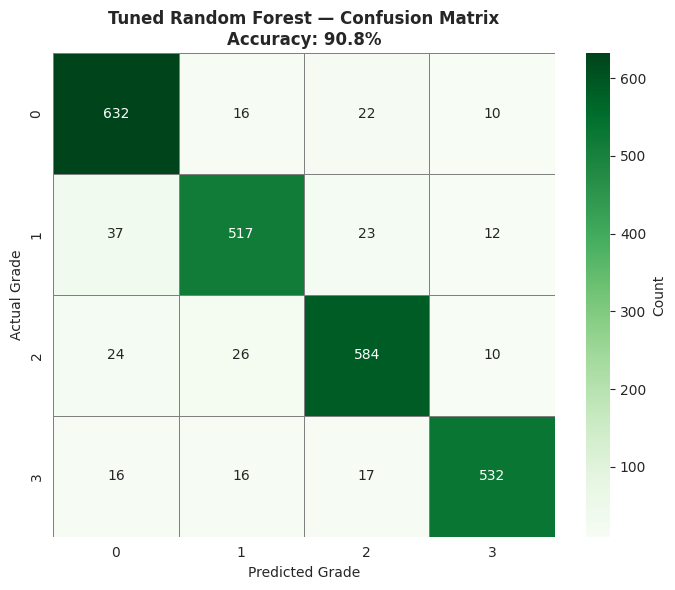

✅ Saved: confusion_matrix_rf_tuned.png


In [ ]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned, labels=grade_labels)

fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens",
            xticklabels=grade_labels, yticklabels=grade_labels,
            linewidths=0.5, linecolor="gray", ax=ax, cbar_kws={"label": "Count"})
ax.set_xlabel("Predicted Grade")
ax.set_ylabel("Actual Grade")
ax.set_title(f"Tuned Random Forest — Confusion Matrix\nAccuracy: {acc_tuned:.1%}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix_rf_tuned.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: confusion_matrix_rf_tuned.png")

### 9.2 Before vs After Tuning

                  Model  Test Accuracy
Random Forest (default)        0.90417
  Random Forest (tuned)        0.90818


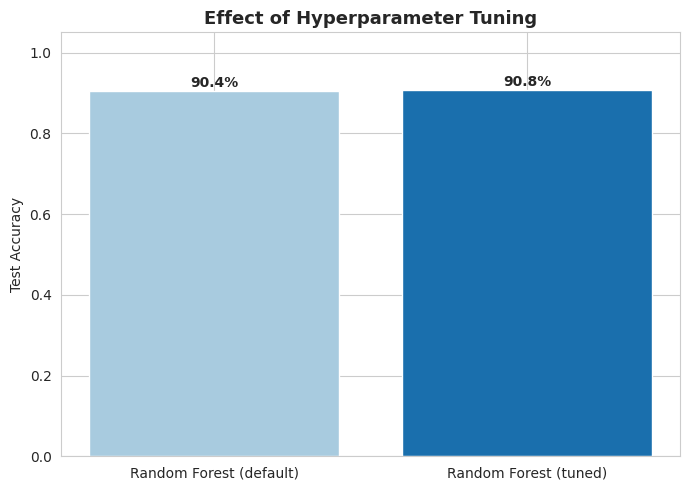

✅ Saved: hyperparameter_comparison.png


In [ ]:
tuning_compare = pd.DataFrame({
    "Model": ["Random Forest (default)", "Random Forest (tuned)"],
    "Test Accuracy": [acc_rf, acc_tuned]
})
print(tuning_compare.to_string(index=False))

plt.figure(figsize=(7,5))
bars = plt.bar(tuning_compare["Model"], tuning_compare["Test Accuracy"], color=["#a8cbdf", "#1a6fad"], edgecolor="white")
for bar, val in zip(bars, tuning_compare["Test Accuracy"]):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.1%}", ha="center", fontweight="bold")
plt.ylim(0, 1.05)
plt.ylabel("Test Accuracy")
plt.title("Effect of Hyperparameter Tuning", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("hyperparameter_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: hyperparameter_comparison.png")